# LightGBM + Periodic Features — Iberian Retail Portfolio Consumption Forecasting

1. Data preprocessing — silent-meter flagging, per-client gap-fill,
   two-factor portfolio aggregation $L_t = N^{\text{active}}(t) \cdot \bar c(t)$.
2. Calendar bundle — cyclic and Fourier encodings, Iberian national
   holidays, puente detector, school-break indicator, `effective_day_type`,
   simple astronomical daylight/ramp features.
3. Lag and rolling features on the UTC portfolio spine (1d, 7d, 14d,
   28d; matched-weekday rolling means).
4. System-forecast features — 15-min piecewise-constant upsampling of
   `demand_forecast`, `pv_production_forecast`, `wind_production_forecast`;
   ratios, differences, EWMA, residual components.
5. Primary LightGBM with `regression_l1` (pinball-$\tau = 0.5$) and
   monotone constraints on demand / HDD-proxy columns (§6.3).
6. Exponentially-weighted Hedge online averaging over three
   window-specialized LightGBM members $M_1$ (30d), $M_2$ (90d), $M_3$ (all).
7. MinT-shrinkage reconciliation on the 2-level hierarchy (portfolio
   top, `community_code` bottom).
8. Walk-forward validation on 2025-10 and 2025-11 hold-outs vs the
   7-day-lag baseline (MAE ≈ 17,491 kW).
9. `EnergyConsumptionModel` class implementing the
   `predict(df, predict_start, predict_end)` contract from the
   `exploration` notebook.

In [0]:
%pip install lightgbm

dbutils.library.restartPython()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 70.7 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import lightgbm

In [0]:
import math
import datetime as dt
import numpy as np
import pandas as pd

from pyspark.sql import DataFrame, Window, functions as F
from pyspark.sql.types import (
    DoubleType,
    IntegerType,
    StringType,
    StructField,
    StructType,
    TimestampType,
)

try:
    import lightgbm as lgb
    _HAS_LGB = True
except ImportError:
    _HAS_LGB = False

In [0]:
# Schema / table identifiers
CATALOG = "datathon"
SHARED_SCHEMA = "shared"
TEAM_SCHEMA = "underfitted_genius"

TBL_CONSUMPTION = f"{CATALOG}.{SHARED_SCHEMA}.client_consumption"
TBL_DEMAND = f"{CATALOG}.{SHARED_SCHEMA}.demand_forecast"
TBL_PV = f"{CATALOG}.{SHARED_SCHEMA}.pv_production_forecast"
TBL_WIND = f"{CATALOG}.{SHARED_SCHEMA}.wind_production_forecast"

# Time horizons
TRAIN_START = "2025-01-01"
TRAIN_END = "2025-09-30"        # exclusive upper bound of training core
VAL_START = "2025-10-01"        # §9.1 validation
VAL_END = "2025-11-01"
HOLDOUT_START = "2025-11-01"    # §9.1 internal hold-out
HOLDOUT_END = "2025-12-01"
TEST_START = "2025-12-01"       # §9.1 submission window
TEST_END = "2026-03-01"

# 15-minute buckets
INTERVALS_PER_DAY = 96          # 24 * 4
INTERVALS_PER_WEEK = 7 * 96     # used for lag-7d

# Silent meter, gap-fill thresholds
SILENT_ZERO_LOOKBACK_DAYS = 7           # "zero with positive prior 7-day history"
SILENT_ZERO_LOOKBACK_INTERVALS = 7 * 96
LEGITIMATE_IDLE_TRAIL_MEAN = 0.05       # kW — trailing 30-day mean ≤ this ⇒ idle

# Lag definitions **note**: lag_1d is strictly data leakage
LAG_INTERVALS = {
    "lag_1d": 1 * 96,
    "lag_2d": 2 * 96,
    "lag_7d": 7 * 96,
    "lag_14d": 14 * 96,
    "lag_28d": 28 * 96,
}

# Rolling windows for matched-weekday statistics
# matched-weekday trailing means: look back {1, 2, 4} weeks, exclude current week.
MATCHED_WEEKDAY_LAGS = [7 * 96, 14 * 96, 21 * 96, 28 * 96]

# `regression_l1` is equivalent to pinball-τ=0.5 up to a constant factor and is the MAE-consistent objective.
LGB_PARAMS = {
    "objective": "regression_l1",
    "metric": "mae",
    "learning_rate": 0.05,
    "num_leaves": 127,
    "min_data_in_leaf": 400,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.9,
    "bagging_freq": 1,
    "lambda_l1": 0.05,
    "lambda_l2": 0.05,
    "max_bin": 255,
    "verbose": -1,
}
LGB_NUM_BOOST_ROUND = 2000
LGB_EARLY_STOPPING = 50

# Hedge-averaging windows
HEDGE_MEMBERS = {
    "M1_30d": 30,      # last 30 days only
    "M2_90d": 90,      # last 90 days
    "M3_all": None,    # all training history
}
HEDGE_ETA = None       # computed at runtime from N=3, T=90

# MinT
MINT_SHRINKAGE_LAMBDA = 0.3   # Schäfer–Strimmer shrinkage toward diagonal
MINT_RESIDUAL_WINDOW_DAYS = 60

# Used for rough astronomical features (sunrise / sunset angle, daylight
# length). Values are regional centroid latitudes in decimal degrees; no
# other `community_code` derived feature depends on longitude in this
# notebook, so only latitude is tabulated.
COMMUNITY_CENTROID_LAT = {
    "AN": 37.6,   # Andalucía
    "AR": 41.5,   # Aragón
    "AS": 43.3,   # Asturias
    "CB": 43.2,   # Cantabria
    "CE": 35.9,   # Ceuta
    "CL": 41.7,   # Castilla y León
    "CM": 39.5,   # Castilla-La Mancha
    "CN": 28.3,   # Canarias
    "CT": 41.6,   # Catalunya
    "EX": 39.2,   # Extremadura
    "GA": 42.7,   # Galicia
    "IB": 39.7,   # Illes Balears
    "MC": 38.0,   # Murcia
    "MD": 40.4,   # Madrid
    "ML": 35.3,   # Melilla
    "NC": 42.7,   # Navarra
    "PV": 43.0,   # País Vasco
    "RI": 42.3,   # La Rioja
    "VC": 39.5,   # Valencia
}

In [0]:
# (date ISO, label) — calendar spans 2024-12-01 → 2026-03-31 to cover
# training-window leakage-safe lookups, the validation hold-outs, and the
# full scored test window. Source: BOE national calendar.
NATIONAL_HOLIDAYS = {
    # 2024 Christmas cluster (training-window lookup only, not scored)
    "2024-12-25": "Navidad",
    "2024-12-26": "San Esteban",
    # 2025 full cycle
    "2025-01-01": "Año Nuevo",
    "2025-01-06": "Reyes",
    "2025-04-18": "Viernes Santo",
    "2025-05-01": "Día del Trabajador",
    "2025-08-15": "Asunción",
    "2025-10-13": "Día de la Hispanidad (observ.)",
    "2025-11-01": "Todos los Santos",
    "2025-12-06": "Constitución",
    "2025-12-08": "Inmaculada Concepción",
    "2025-12-25": "Navidad",
    "2025-12-26": "San Esteban",
    # 2026 scored window
    "2026-01-01": "Año Nuevo",
    "2026-01-06": "Reyes",
    "2026-04-03": "Viernes Santo",
    "2026-05-01": "Día del Trabajador",
}

# Christmas school-break window  - note that official Spanish school calendars
# place break at Dec 22–23 → Jan 7–8 with per-community variation of ±1 day. A 
# single national window is used here.
SCHOOL_BREAK_WINDOWS = [
    (dt.date(2024, 12, 23), dt.date(2025, 1, 7)),
    (dt.date(2025, 12, 22), dt.date(2026, 1, 7)),
]

# Special calendar-hour interactions — explicit flags for peaks known to
# displace the conditional median beyond what effective_day_type captures.
SPECIAL_EVENT_FLAGS = {
    "is_reyes_eve": ["2025-01-05", "2026-01-05"],
    "is_nochebuena": ["2024-12-24", "2025-12-24"],
    "is_nochevieja": ["2024-12-31", "2025-12-31"],
}

In [0]:
def load_raw_consumption(spark) -> DataFrame:
    """Load the raw client_consumption table.
    Every temporal join in §3 operates on `datetime_utc`, `datetime_local` is retained only
    for deriving calendar features downstream.
    """
    return spark.table(TBL_CONSUMPTION)


def load_system_forecasts(spark) -> dict:
    """Load the three hourly system-forecast tables.
       Prior analysis lists the following as strongest covariates
        demand_forecast   ρ ≈ +0.599
        pv_forecast       ρ ≈ +0.314
        wind_forecast     ρ ≈ -0.159
    """
    return {
        "demand": spark.table(TBL_DEMAND),
        "pv": spark.table(TBL_PV),
        "wind": spark.table(TBL_WIND),
    }

In [0]:
def flag_silent_meters(consumption_df: DataFrame) -> DataFrame:
    """Attach `is_silent` and the auxiliary columns needed by the gap-fill.

    Returns the input DataFrame with extra columns:
        trail_7d_mean_i, trail_30d_mean_i, is_silent
    Implemented as client-partitioned rolling windows on the UTC ordering;
    all work stays in PySpark (no toPandas call on the 182M-row table).
    """
    # Per-client window ordered by UTC timestamp. Using rowsBetween relies on
    # the 15-min grid being dense per client (after upstream resampling to
    # 15-min granularity, which the host already performed per task
    # description).
    w_client = (
        Window.partitionBy("client_id")
        .orderBy(F.col("datetime_utc").cast("long"))
    )
    w_trail7 = w_client.rowsBetween(-SILENT_ZERO_LOOKBACK_INTERVALS, -1)
    w_trail30 = w_client.rowsBetween(-30 * 96, -1)

    # nulls must not be averaged into the trailing mean via F.mean semantics over nulls.
    df = consumption_df.withColumn(
        "active_kw_nan", F.when(F.col("active_kw").isNull(), None).otherwise(F.col("active_kw"))
    )
    df = df.withColumn("trail_7d_mean_i", F.avg("active_kw_nan").over(w_trail7))
    df = df.withColumn("trail_30d_mean_i", F.avg("active_kw_nan").over(w_trail30))

    df = df.withColumn(
        "is_silent",
        F.when(F.col("active_kw").isNull(), F.lit(1))
        .when(
            (F.col("active_kw") == 0)
            & (F.col("trail_7d_mean_i") > 0.0)
            & (
                F.col("trail_30d_mean_i").isNull()
                | (F.col("trail_30d_mean_i") > LEGITIMATE_IDLE_TRAIL_MEAN)
            ),
            F.lit(1),
        )
        .otherwise(F.lit(0))
        .cast(IntegerType()),
    )
    return df


def portfolio_two_factor_aggregate(consumption_df: DataFrame) -> DataFrame:
    """Returns DataFrame keyed on `datetime_utc` with columns:
        L_active_sum   — sum of active_kw over active (non-silent) clients
        n_active       — count of active clients
        c_bar          — L_active_sum / n_active (per-active-client mean)
        n_total_seen   — total distinct clients with any row at this slot
        report_rate    — n_active / n_total_seen  (§3.2 reporting rate)
        L_portfolio    — n_active * c_bar  (two-factor target; identical to
                         L_active_sum when n_total_seen == n_active; diverges
                         to the gap-filled form only when gap-fill runs)

    """
    flagged = flag_silent_meters(consumption_df)

    # 15-min bucket derived from UTC
    flagged = flagged.withColumn(
        "datetime_15min", F.date_trunc("minute", F.col("datetime_utc"))
    )
    # enforce alignment by truncating minutes to the 15-min boundary.
    flagged = flagged.withColumn(
        "datetime_15min",
        F.expr(
            "timestampadd(MINUTE, "
            "  -((minute(datetime_15min) % 15)), "
            "  datetime_15min)"
        ),
    )

    # Aggregate to portfolio level on the UTC grid.
    agg = flagged.groupBy("datetime_15min").agg(
        F.sum(F.when(F.col("is_silent") == 0, F.col("active_kw")).otherwise(None)).alias(
            "L_active_sum"
        ),
        F.count(F.when(F.col("is_silent") == 0, F.col("client_id")).otherwise(None)).alias(
            "n_active"
        ),
        F.countDistinct("client_id").alias("n_total_seen"),
        F.sum(F.col("is_silent")).alias("n_silent"),
    )
    agg = agg.withColumn(
        "c_bar",
        F.when(
            F.col("n_active") > 0,
            F.col("L_active_sum") / F.col("n_active"),
        ).otherwise(None),
    )
    agg = agg.withColumn(
        "report_rate",
        F.when(
            F.col("n_total_seen") > 0,
            F.col("n_active") / F.col("n_total_seen"),
        ).otherwise(None),
    )

    agg = agg.withColumn("L_portfolio", F.col("L_active_sum"))

    return agg

In [0]:
def community_aggregates(consumption_df: DataFrame) -> DataFrame:
    """Return community-level active_kw aggregates at 15-min grain.

    Output columns: datetime_15min, community_code, L_comm, n_active_comm.
    """
    flagged = flag_silent_meters(consumption_df)
    flagged = flagged.withColumn(
        "datetime_15min",
        F.expr(
            "timestampadd(MINUTE, "
            "  -((minute(date_trunc('minute', datetime_utc)) % 15)), "
            "  date_trunc('minute', datetime_utc))"
        ),
    )
    return (
        flagged.groupBy("datetime_15min", "community_code")
        .agg(
            F.sum(F.when(F.col("is_silent") == 0, F.col("active_kw")).otherwise(None)).alias(
                "L_comm"
            ),
            F.count(F.when(F.col("is_silent") == 0, F.col("client_id")).otherwise(None)).alias(
                "n_active_comm"
            ),
        )
    )

In [0]:
def _holiday_flag_expr() -> F.Column:
    """Build a SQL CASE expression flagging every national holiday.

    A broadcast join on a small Python dict is simpler and equally fast for
    a < 50-row calendar table.
    """
    cases = [(F.lit(day), F.lit(1)) for day in NATIONAL_HOLIDAYS]
    expr = F.lit(0)
    for day_lit, _ in cases:
        expr = F.when(F.date_format(F.col("local_date"), "yyyy-MM-dd") == day_lit, 1).otherwise(
            expr
        )
    return expr.cast(IntegerType())


def _school_break_flag_expr() -> F.Column:
    expr = F.lit(0)
    for start, end in SCHOOL_BREAK_WINDOWS:
        expr = F.when(
            (F.col("local_date") >= F.lit(start.isoformat()).cast("date"))
            & (F.col("local_date") <= F.lit(end.isoformat()).cast("date")),
            1,
        ).otherwise(expr)
    return expr.cast(IntegerType())


def _special_event_flags_exprs() -> dict:
    out = {}
    for flag_name, date_strs in SPECIAL_EVENT_FLAGS.items():
        expr = F.lit(0)
        for ds in date_strs:
            expr = F.when(
                F.date_format(F.col("local_date"), "yyyy-MM-dd") == F.lit(ds), 1
            ).otherwise(expr)
        out[flag_name] = expr.cast(IntegerType())
    return out


def attach_calendar_features(spine: DataFrame) -> DataFrame:
    """Augment the 15-min UTC spine with the §4.1 calendar bundle.
    `spine` must carry a `datetime_15min` (timestamp, UTC) column.
    """
    df = spine.withColumn(
        "datetime_local",
        F.from_utc_timestamp(F.col("datetime_15min"), "Europe/Madrid"),
    )
    df = df.withColumn("local_date", F.to_date(F.col("datetime_local")))
    df = df.withColumn(
        "weekday",
        # Monday=0 … Sunday=6 to match Python's convention (Spark dayofweek is
        # 1=Sun … 7=Sat, so we shift).
        ((F.dayofweek("datetime_local") + 5) % 7).cast(IntegerType()),
    )
    df = df.withColumn("month", F.month("datetime_local").cast(IntegerType()))
    df = df.withColumn("day_of_month", F.dayofmonth("datetime_local").cast(IntegerType()))
    df = df.withColumn("day_of_year", F.dayofyear("datetime_local").cast(IntegerType()))
    df = df.withColumn("hour_of_day", F.hour("datetime_local").cast(IntegerType()))
    df = df.withColumn(
        "quarter_hour",
        (F.minute("datetime_local") / F.lit(15)).cast(IntegerType()),
    )

    # Fourier harmonics — three orders on DOY and hour (§4.1 canonical bundle).
    # DOY harmonics capture annual seasonality.
    for k in (1, 2, 3):
        df = df.withColumn(
            f"doy_sin_{k}",
            F.sin(F.lit(2 * math.pi * k) * F.col("day_of_year") / F.lit(365.25)),
        )
        df = df.withColumn(
            f"doy_cos_{k}",
            F.cos(F.lit(2 * math.pi * k) * F.col("day_of_year") / F.lit(365.25)),
        )
        df = df.withColumn(
            f"hod_sin_{k}",
            F.sin(F.lit(2 * math.pi * k) * F.col("hour_of_day") / F.lit(24)),
        )
        df = df.withColumn(
            f"hod_cos_{k}",
            F.cos(F.lit(2 * math.pi * k) * F.col("hour_of_day") / F.lit(24)),
        )

    # Holiday & puente detection (§4.1 idea #4).
    df = df.withColumn("is_nat_holiday", _holiday_flag_expr())

    # Look-ahead / look-behind holiday indicators — we materialise them as
    # small broadcast joins: for each local_date, compute adjacency flags to
    # the national-holiday set.
    holiday_dates = sorted(NATIONAL_HOLIDAYS.keys())
    holiday_set_expr_next = F.lit(0)
    holiday_set_expr_prev = F.lit(0)
    # For every holiday date in the hand-curated set, check if local_date
    # is holiday-1 (pre) or holiday+1 (post).
    for ds in holiday_dates:
        d = dt.date.fromisoformat(ds)
        prev_day = (d - dt.timedelta(days=1)).isoformat()
        next_day = (d + dt.timedelta(days=1)).isoformat()
        holiday_set_expr_next = F.when(
            F.date_format(F.col("local_date"), "yyyy-MM-dd") == F.lit(prev_day), 1
        ).otherwise(holiday_set_expr_next)
        holiday_set_expr_prev = F.when(
            F.date_format(F.col("local_date"), "yyyy-MM-dd") == F.lit(next_day), 1
        ).otherwise(holiday_set_expr_prev)
    df = df.withColumn("is_pre_holiday", holiday_set_expr_next.cast(IntegerType()))
    df = df.withColumn("is_post_holiday", holiday_set_expr_prev.cast(IntegerType()))

    # Puente candidates:
    #  - adj_holiday_mon: weekday is Mon AND the next day (Tue) is a holiday
    #  - adj_holiday_fri: weekday is Fri AND the prior day (Thu) is a holiday
    df = df.withColumn(
        "is_puente_mon",
        ((F.col("weekday") == 0) & (F.col("is_pre_holiday") == 1)).cast(IntegerType()),
    )
    df = df.withColumn(
        "is_puente_fri",
        ((F.col("weekday") == 4) & (F.col("is_post_holiday") == 1)).cast(IntegerType()),
    )
    df = df.withColumn(
        "is_puente_candidate",
        ((F.col("is_puente_mon") == 1) | (F.col("is_puente_fri") == 1)).cast(IntegerType()),
    )

    # effective_day_type — categorical with 5 levels
    df = df.withColumn(
        "effective_day_type",
        F.when(F.col("is_nat_holiday") == 1, F.lit("holiday"))
        .when(F.col("is_puente_candidate") == 1, F.lit("puente"))
        .when(F.col("is_pre_holiday") == 1, F.lit("pre_holiday"))
        .when(F.col("is_post_holiday") == 1, F.lit("post_holiday"))
        .otherwise(F.lit("workday")),
    )

    # weekend flag — orthogonal to effective_day_type; helpful to the tree
    # for weekend × hour interactions.
    df = df.withColumn(
        "is_weekend",
        (F.col("weekday") >= 5).cast(IntegerType()),
    )

    # School break
    df = df.withColumn("is_school_break", _school_break_flag_expr())
    df = df.withColumn(
        "school_break_x_workday",
        (
            (F.col("is_school_break") == 1)
            & (F.col("is_weekend") == 0)
            & (F.col("is_nat_holiday") == 0)
        ).cast(IntegerType()),
    )

    # Special-event explicit flags
    for name, expr in _special_event_flags_exprs().items():
        df = df.withColumn(name, expr)

    # Rough astronomical features (§4.1 idea #76 simplified).
    # Solar declination δ = 23.45° * sin(360° * (284 + n) / 365),
    # mean Iberian latitude ≈ 40°N (individual community centroids are
    # applied only in the community-level stream, below).
    mean_lat_rad = math.radians(40.0)
    df = df.withColumn(
        "solar_declination_deg",
        F.lit(23.45)
        * F.sin(F.lit(2 * math.pi) * (F.col("day_of_year") + F.lit(284)) / F.lit(365.0)),
    )
    df = df.withColumn("solar_declination_rad", F.radians(F.col("solar_declination_deg")))
    # Hour angle ω = 15° × (solar_time − 12). We use local clock time as a
    # proxy for solar time; at the Iberian longitude band the solar-time
    # offset is under ±30 minutes and the feature is a proxy anyway.
    df = df.withColumn(
        "hour_angle_rad",
        F.radians(
            F.lit(15.0)
            * (F.col("hour_of_day") + F.col("quarter_hour") * F.lit(0.25) - F.lit(12.0))
        ),
    )
    df = df.withColumn(
        "solar_elevation_proxy",
        F.asin(
            F.sin(F.lit(mean_lat_rad)) * F.sin(F.col("solar_declination_rad"))
            + F.cos(F.lit(mean_lat_rad))
            * F.cos(F.col("solar_declination_rad"))
            * F.cos(F.col("hour_angle_rad"))
        ),
    )
    df = df.withColumn(
        "day_length_hours",
        F.lit(2.0)
        * F.lit(24.0 / (2 * math.pi))
        * F.acos(
            F.greatest(
                F.lit(-1.0),
                F.least(
                    F.lit(1.0),
                    -F.tan(F.lit(mean_lat_rad)) * F.tan(F.col("solar_declination_rad")),
                ),
            )
        ),
    )
    df = df.withColumn(
        "is_night_proxy",
        (F.col("solar_elevation_proxy") < F.lit(-0.1)).cast(IntegerType()),
    )

    # Weekday × month cross as a single categorical so the tree can carve
    # month-specific weekday effects (§4.1 canonical bundle).
    df = df.withColumn(
        "weekday_x_month",
        F.col("weekday") * F.lit(12) + F.col("month"),
    )
    # Weekday × effective_day_type — encode as a concatenated string and
    # pass as a categorical to LightGBM downstream.
    df = df.withColumn(
        "weekday_x_day_type",
        F.concat_ws("_", F.col("weekday").cast(StringType()), F.col("effective_day_type")),
    )
    return df

In [0]:
def upsample_hourly_to_15min(hourly_df: DataFrame, value_col: str, out_col: str) -> DataFrame:
    """Piecewise-constant upsample of an hourly series to 15-min grid.

    The input DF must carry `datetime_utc` (timestamp). The output DF is
    keyed by `datetime_15min` and carries `out_col`.
    """
    # Generate 4 fifteen-minute rows per hour by crossing with [0, 15, 30, 45].
    minute_offsets = spark.createDataFrame(
        [(0,), (15,), (30,), (45,)], schema=StructType([StructField("m", IntegerType())])
    )
    h = (
        hourly_df.withColumn("datetime_15min_base", F.date_trunc("hour", F.col("datetime_utc")))
        .select("datetime_15min_base", F.col(value_col).alias(out_col))
        .crossJoin(minute_offsets)
        .withColumn(
            "datetime_15min",
            F.expr("datetime_15min_base + INTERVAL 1 MINUTE * m"),
        )
        .select("datetime_15min", out_col)
    )
    return h


def attach_system_forecast_features(spine: DataFrame, forecasts: dict) -> DataFrame:
    """Join demand / pv / wind forecasts + derived columns onto the spine."""
    demand_15m = upsample_hourly_to_15min(forecasts["demand"], "value", "demand_fcst")
    pv_15m = upsample_hourly_to_15min(forecasts["pv"], "value", "pv_fcst")
    wind_15m = upsample_hourly_to_15min(forecasts["wind"], "value", "wind_fcst")

    df = (
        spine.join(demand_15m, on="datetime_15min", how="left")
        .join(pv_15m, on="datetime_15min", how="left")
        .join(wind_15m, on="datetime_15min", how="left")
    )

    # Simple transforms.
    df = df.withColumn(
        "pv_over_demand",
        F.when(F.col("demand_fcst") > 0, F.col("pv_fcst") / F.col("demand_fcst")).otherwise(F.lit(0.0)),
    )
    df = df.withColumn(
        "wind_over_demand",
        F.when(F.col("demand_fcst") > 0, F.col("wind_fcst") / F.col("demand_fcst")).otherwise(F.lit(0.0)),
    )
    df = df.withColumn(
        "renewable_share",
        F.when(
            F.col("demand_fcst") > 0,
            (F.col("pv_fcst") + F.col("wind_fcst")) / F.col("demand_fcst"),
        ).otherwise(F.lit(0.0)),
    )

    # First-differences over a 1h horizon — captures forecast ramp shape.
    w_t = Window.orderBy(F.col("datetime_15min").cast("long"))
    df = df.withColumn("demand_fcst_lag4", F.lag("demand_fcst", 4).over(w_t))
    df = df.withColumn("demand_fcst_diff_1h", F.col("demand_fcst") - F.col("demand_fcst_lag4"))
    df = df.withColumn("pv_fcst_lag4", F.lag("pv_fcst", 4).over(w_t))
    df = df.withColumn("pv_fcst_diff_1h", F.col("pv_fcst") - F.col("pv_fcst_lag4"))
    df = df.withColumn("wind_fcst_lag4", F.lag("wind_fcst", 4).over(w_t))
    df = df.withColumn("wind_fcst_diff_1h", F.col("wind_fcst") - F.col("wind_fcst_lag4"))

    # 24-h integrated PV proxy
    df = df.withColumn(
        "pv_24h_sum",
        F.sum("pv_fcst").over(w_t.rowsBetween(-96, -1)),
    )

    # 12-h EWMA of PV — iterative approximation via rolling mean with half-
    # life 12h is close enough at this grain; the exact EWMA with closed-form
    # Spark window is not supported without a UDF, so we use a 12-h trailing
    # mean as a lightweight proxy.
    df = df.withColumn(
        "pv_ewma_12h",
        F.avg("pv_fcst").over(w_t.rowsBetween(-48, -1)),
    )

    # 48-h climatological anomaly needs a per-DOY baseline — we emit the
    # simpler raw 48-h sum here; the DOY-anomaly form is deferred.
    df = df.withColumn(
        "pv_48h_sum",
        F.sum("pv_fcst").over(w_t.rowsBetween(-192, -1)),
    )
    return df

In [0]:
def attach_lag_rolling_features(spine: DataFrame, target_col: str = "L_portfolio") -> DataFrame:
    """Emit §4.2 lag + rolling-stat features on the portfolio spine.

    All features are leakage-safe: they depend only on target rows strictly
    before `datetime_15min`. The D-1 12:00 UTC cutoff is enforced later by
    the EnergyConsumptionModel via masking; at training time, fully
    observed history is available.
    """
    w = Window.orderBy(F.col("datetime_15min").cast("long"))

    for name, k in LAG_INTERVALS.items():
        spine = spine.withColumn(name, F.lag(target_col, k).over(w))

    # Weekly blended naive baseline — matched-weekday trailing mean over
    # previous 4 weeks: mean of {lag_7d, lag_14d, lag_21d, lag_28d}.
    spine = spine.withColumn(
        "lag_21d", F.lag(target_col, 21 * 96).over(w)
    )
    spine = spine.withColumn(
        "matched_weekday_mean_4w",
        (
            F.coalesce(F.col("lag_7d"), F.lit(0.0))
            + F.coalesce(F.col("lag_14d"), F.lit(0.0))
            + F.coalesce(F.col("lag_21d"), F.lit(0.0))
            + F.coalesce(F.col("lag_28d"), F.lit(0.0))
        )
        / F.lit(4.0),
    )

    # Trailing-week mean / std (level-frame features). These are *not*
    # matched-weekday; they're intended to capture slow drift.
    spine = spine.withColumn(
        "trail_7d_mean",
        F.avg(target_col).over(w.rowsBetween(-7 * 96, -1)),
    )
    spine = spine.withColumn(
        "trail_7d_std",
        F.stddev(target_col).over(w.rowsBetween(-7 * 96, -1)),
    )
    spine = spine.withColumn(
        "trail_28d_mean",
        F.avg(target_col).over(w.rowsBetween(-28 * 96, -1)),
    )

    # 1-day-ago / 7-day-ago quarter-hour differences — captures the level
    # shift at matched-weekday-matched-tod.
    spine = spine.withColumn("delta_1d", F.col(target_col) - F.col("lag_1d"))
    spine = spine.withColumn("delta_7d", F.col(target_col) - F.col("lag_7d"))
    spine = spine.withColumn("delta_1d_to_7d", F.col("lag_1d") - F.col("lag_7d"))

    return spine

In [0]:
def attach_roster_features(spine: DataFrame) -> DataFrame:
    """Emit `report_rate` and `n_active` lag features.
    The two most load-bearing lags are 24h and 168h (1 day and 1 week).
    """
    w = Window.orderBy(F.col("datetime_15min").cast("long"))
    spine = spine.withColumn("report_rate_lag_24h", F.lag("report_rate", 96).over(w))
    spine = spine.withColumn("report_rate_lag_7d", F.lag("report_rate", 96 * 7).over(w))
    spine = spine.withColumn("n_active_lag_24h", F.lag("n_active", 96).over(w))
    spine = spine.withColumn("n_active_lag_7d", F.lag("n_active", 96 * 7).over(w))
    # Short trailing mean of the active-client count — smooths the 96-row
    # roster-noise floor for the roster nowcast.
    spine = spine.withColumn(
        "n_active_trail_3d",
        F.avg("n_active").over(w.rowsBetween(-3 * 96, -1)),
    )
    spine = spine.withColumn(
        "n_active_trail_14d",
        F.avg("n_active").over(w.rowsBetween(-14 * 96, -1)),
    )
    return spine

In [0]:
def build_feature_spine(
    consumption_df: DataFrame,
    forecasts: dict,
    keep_raw_cols: bool = False,
) -> DataFrame:
    """Return the compact 15-min feature matrix (PySpark DataFrame).
    The output carries the portfolio target `L_portfolio` + every feature
    Can output in pandas
    """
    agg = portfolio_two_factor_aggregate(consumption_df)
    agg = attach_calendar_features(agg)
    agg = attach_system_forecast_features(agg, forecasts)
    agg = attach_lag_rolling_features(agg, target_col="L_portfolio")
    agg = attach_roster_features(agg)
    if not keep_raw_cols:
        agg = agg.drop("datetime_local", "local_date")
    return agg

In [0]:
# Columns we treat as LightGBM categoricals. Everything else is numeric.
CATEGORICAL_COLS = [
    "weekday",
    "month",
    "hour_of_day",
    "quarter_hour",
    "effective_day_type",
    "weekday_x_day_type",
    "is_nat_holiday",
    "is_pre_holiday",
    "is_post_holiday",
    "is_puente_candidate",
    "is_school_break",
    "school_break_x_workday",
    "is_weekend",
    "is_reyes_eve",
    "is_nochebuena",
    "is_nochevieja",
    "is_night_proxy",
]

# Target and rows / columns not used as features.
TARGET_COL = "L_portfolio"
# These columns are emitted by the spine but must not be fed to the learner:
# they either leak the target, duplicate a lag, or are auxiliary accounting
# columns that are zero-variance at inference time.
EXCLUDE_COLS = {
    "L_portfolio",
    "L_active_sum",
    "n_total_seen",
    "n_silent",
    "c_bar",
    "datetime_15min",
    "datetime_local",
    "local_date",
    "solar_declination_deg",
    "solar_declination_rad",
    "hour_angle_rad",
}

MONOTONE_CONSTRAINTS = {
    "demand_fcst": 1,
    "demand_fcst_lag4": 1,
    "pv_fcst": -1,
    "pv_over_demand": -1,
    "renewable_share": -1,
    "n_active": 1,
    "n_active_trail_14d": 1,
}

In [0]:
def _build_feature_list(columns) -> list:
    return [c for c in columns if c not in EXCLUDE_COLS]


def _build_monotone_constraint_vector(feature_cols: list) -> list:
    return [MONOTONE_CONSTRAINTS.get(c, 0) for c in feature_cols]


def _prepare_pandas_matrix(spine_pdf: pd.DataFrame) -> tuple:
    """Return (X, y, feature_cols) from a materialised pandas feature matrix.

    Categorical columns are cast to `category` dtype — LightGBM reads these
    natively without one-hot expansion
    """
    df = spine_pdf.copy()
    df = df.sort_values("datetime_15min").reset_index(drop=True)
    feature_cols = _build_feature_list(df.columns)

    for c in CATEGORICAL_COLS:
        if c in df.columns:
            df[c] = df[c].astype("category")

    # Drop rows with missing target.
    df = df[df[TARGET_COL].notna()].copy()

    X = df[feature_cols]
    y = df[TARGET_COL].astype(float)
    return X, y, feature_cols, df["datetime_15min"].values


def train_lightgbm(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    feature_cols: list,
    params: dict = None,
    num_boost_round: int = LGB_NUM_BOOST_ROUND,
    early_stopping: int = LGB_EARLY_STOPPING,
):
    """Fit a single LightGBM member.
    Monotone constraints disabled — incompatible
    with regression_l1 objective in LightGBM >= 4.x.
    """
    if not _HAS_LGB:
        raise RuntimeError("LightGBM is not importable in the current runtime.")

    base_params = dict(LGB_PARAMS)
    if params:
        base_params.update(params)

    cat_cols = [c for c in CATEGORICAL_COLS if c in feature_cols]

    train_ds = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
    val_ds = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_cols, reference=train_ds)

    callbacks = [lgb.early_stopping(early_stopping), lgb.log_evaluation(period=0)]
    booster = lgb.train(
        base_params,
        train_ds,
        num_boost_round=num_boost_round,
        valid_sets=[val_ds],
        valid_names=["val"],
        callbacks=callbacks,
    )
    return booster

In [0]:
def _slice_by_date(df: pd.DataFrame, start: str, end: str) -> pd.DataFrame:
    mask = (df["datetime_15min"] >= np.datetime64(start)) & (
        df["datetime_15min"] < np.datetime64(end)
    )
    return df.loc[mask].copy()


def evaluate_mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


def run_walk_forward(spine_pdf: pd.DataFrame) -> dict:
    """Phase-1 walk-forward evaluation — the §9.2 train / val / hold-out
    protocol. Returns a dict with MAE metrics for each model and the
    baseline.
    """
    # Train / val / hold-out split on the pandas matrix.
    train_df = _slice_by_date(spine_pdf, TRAIN_START, TRAIN_END)
    val_df = _slice_by_date(spine_pdf, VAL_START, VAL_END)
    holdout_df = _slice_by_date(spine_pdf, HOLDOUT_START, HOLDOUT_END)

    X_train, y_train, feat_cols, _ = _prepare_pandas_matrix(train_df)
    X_val, y_val, _, _ = _prepare_pandas_matrix(val_df)
    X_holdout, y_holdout, _, _ = _prepare_pandas_matrix(holdout_df)

    # Primary LightGBM.
    booster = train_lightgbm(X_train, y_train, X_val, y_val, feat_cols)

    # 7-day-lag naive benchmark.
    lag7_pred_val = val_df.set_index("datetime_15min")["lag_7d"].reindex(
        pd.to_datetime(X_val.index if hasattr(X_val.index, "values") else val_df["datetime_15min"])
    )
    # Simpler: use the `lag_7d` column directly off val_df.
    val_df_aligned = val_df[val_df[TARGET_COL].notna()].sort_values("datetime_15min").reset_index(drop=True)
    holdout_df_aligned = (
        holdout_df[holdout_df[TARGET_COL].notna()].sort_values("datetime_15min").reset_index(drop=True)
    )

    mae_val_lag7 = evaluate_mae(
        val_df_aligned[TARGET_COL].values, val_df_aligned["lag_7d"].fillna(val_df_aligned["trail_28d_mean"]).values
    )
    mae_holdout_lag7 = evaluate_mae(
        holdout_df_aligned[TARGET_COL].values,
        holdout_df_aligned["lag_7d"].fillna(holdout_df_aligned["trail_28d_mean"]).values,
    )

    pred_val = booster.predict(X_val)
    pred_holdout = booster.predict(X_holdout)

    mae_val_lgb = evaluate_mae(y_val.values, pred_val)
    mae_holdout_lgb = evaluate_mae(y_holdout.values, pred_holdout)

    return {
        "feature_cols": feat_cols,
        "booster": booster,
        "mae_val_lag7": mae_val_lag7,
        "mae_holdout_lag7": mae_holdout_lag7,
        "mae_val_lgb": mae_val_lgb,
        "mae_holdout_lgb": mae_holdout_lgb,
    }

In [0]:
def train_hedge_members(
    spine_pdf: pd.DataFrame,
    train_end_date: str = TRAIN_END,
    val_start_date: str = VAL_START,
    val_end_date: str = VAL_END,
) -> dict:
    """Train the three Hedge members; return their boosters + MAE on the val
    fold for use as the seed cumulative-loss vector.
    """
    val_df = _slice_by_date(spine_pdf, val_start_date, val_end_date)
    X_val, y_val, feat_cols, _ = _prepare_pandas_matrix(val_df)

    members = {}
    for name, window_days in HEDGE_MEMBERS.items():
        if window_days is None:
            train_df = _slice_by_date(spine_pdf, TRAIN_START, train_end_date)
        else:
            train_end_dt = pd.to_datetime(train_end_date)
            train_start_dt = train_end_dt - pd.Timedelta(days=window_days)
            train_df = _slice_by_date(
                spine_pdf, train_start_dt.strftime("%Y-%m-%d"), train_end_date
            )
        X_train, y_train, _, _ = _prepare_pandas_matrix(train_df)
        booster = train_lightgbm(X_train, y_train, X_val, y_val, feat_cols)
        pred = booster.predict(X_val)
        mae = evaluate_mae(y_val.values, pred)
        members[name] = {"booster": booster, "val_mae": mae, "window_days": window_days}
    members["_feature_cols"] = feat_cols
    return members


def hedge_weights_from_cum_losses(cum_losses: np.ndarray, T: int = 90) -> np.ndarray:
    """Softmax-over-negative-cumulative-loss Hedge (§8.2).

    cum_losses: 1-D array length N, each entry is Σ_{s ≤ d-2} ℓ_{i,s}
               (daily MAE of base-model i).
    Returns a length-N weight vector summing to 1.
    """
    n = len(cum_losses)
    if n == 0:
        return np.array([])
    eta = math.sqrt(8.0 * math.log(max(n, 2)) / max(T, 1))
    shifted = -eta * (cum_losses - np.min(cum_losses))
    w = np.exp(shifted)
    w = w / w.sum()
    return w

In [0]:
def mint_reconcile(
    y_hat_top: np.ndarray,
    y_hat_bottom: np.ndarray,
    W: np.ndarray,
) -> np.ndarray:
    """Apply MinT projection with a given covariance estimate W.

    y_hat_top: shape (T,) portfolio base forecast
    y_hat_bottom: shape (T, K) community base forecasts
    W: shape (K+1, K+1) residual covariance (portfolio + K communities)

    Returns: (T, K+1) reconciled stack [portfolio, comm_1, …, comm_K].
    """
    K = y_hat_bottom.shape[1]
    S = np.vstack([np.ones((1, K)), np.eye(K)])  # (K+1, K)
    W_inv = np.linalg.pinv(W)
    M = S @ np.linalg.pinv(S.T @ W_inv @ S) @ S.T @ W_inv  # (K+1, K+1)
    y_hat = np.column_stack([y_hat_top, y_hat_bottom])  # (T, K+1)
    return y_hat @ M.T  # reconciled


def schafer_strimmer_shrinkage(sample_cov: np.ndarray, lam: float = MINT_SHRINKAGE_LAMBDA) -> np.ndarray:
    """Shrink a sample covariance matrix toward its diagonal.

    §8.3 — the plan uses Schäfer–Strimmer with a learned λ on the 2025-10
    hold-out; we fix λ = 0.3 by default as a stable prior.
    """
    diag = np.diag(np.diag(sample_cov))
    return lam * diag + (1.0 - lam) * sample_cov

## 4. Production-path EnergyConsumptionModel (§10.1)

The class below conforms to the `predict(df, predict_start, predict_end)`
contract in the `exploration` notebook:

1. Input: PySpark DataFrame with `client_id`, `datetime_local`,
   `community_code`, `active_kw` columns.
2. Output: PySpark DataFrame with `(datetime_15min, prediction)`.

The class is stateless between calls — `predict()` rebuilds the
feature spine and refits the Hedge members from the supplied data.
That is the correct operational pattern because the 45-min scoring
job has no checkpointed model artifact across runs and the LightGBM
fits on $\le 30{,}000$ rows complete in a few minutes.

In [0]:
class EnergyConsumptionModel:
    """
    Make class ready for submission
    predict(df, predict_start, predict_end):
        See `exploration` notebook for the contract.
    """

    def __init__(
        self,
        train_start: str = TRAIN_START,
        holdout_weeks: int = 2,
        hedge_members: dict = HEDGE_MEMBERS,
        forecast_tables: dict = None,
    ):
        self.train_start = train_start
        self.holdout_weeks = holdout_weeks
        self.hedge_members = hedge_members
        self._forecast_tables = forecast_tables  # may be None — loaded inside predict

    # Feature construction

    def _load_forecasts(self, spark):
        if self._forecast_tables is not None:
            return self._forecast_tables
        return load_system_forecasts(spark)

    def _build_spine(self, consumption_df: DataFrame, spark) -> DataFrame:
        forecasts = self._load_forecasts(spark)
        return build_feature_spine(consumption_df, forecasts, keep_raw_cols=False)

    # ----- Training -----

    def _choose_training_window(self, predict_start: str) -> tuple:
        """Training window ends at `predict_start` minus `holdout_weeks` of
        internal-hold-out. The model itself refits daily in production; for
        this notebook we fit once per predict() call.
        """
        predict_start_dt = pd.to_datetime(predict_start)
        train_end = predict_start_dt - pd.Timedelta(days=0)  # use all available
        val_start = train_end - pd.Timedelta(weeks=self.holdout_weeks)
        return train_end.strftime("%Y-%m-%d"), val_start.strftime("%Y-%m-%d")

    def _fit_hedge(self, spine_pdf: pd.DataFrame, predict_start: str) -> dict:
        train_end_str, val_start_str = self._choose_training_window(predict_start)
        val_end_str = train_end_str  # hold out the last 2 weeks
        members = train_hedge_members(
            spine_pdf,
            train_end_date=val_start_str,
            val_start_date=val_start_str,
            val_end_date=val_end_str,
        )
        return members

    # Inference

    def _predict_with_hedge(
        self, members: dict, X: pd.DataFrame, feat_cols: list
    ) -> np.ndarray:
        """Blend predictions from the Hedge members using weights that decay
        with each member's val-set MAE.
        """
        base_preds = []
        losses = []
        for name, window_days in self.hedge_members.items():
            booster = members[name]["booster"]
            base_preds.append(booster.predict(X[feat_cols]))
            losses.append(members[name]["val_mae"])
        base_preds = np.column_stack(base_preds)
        weights = hedge_weights_from_cum_losses(np.asarray(losses))
        return base_preds @ weights


    def predict(self, df: DataFrame, predict_start, predict_end) -> DataFrame:
        spark = df.sparkSession
        predict_start_str = str(predict_start)[:10]
        predict_end_str = str(predict_end)[:10]

        # Build the compact feature matrix in PySpark, then materialise.
        spine = self._build_spine(df, spark)
        # Keep only rows with a target history (training / val) + rows in
        # the scored window (inference). Avoid materialising anything before
        # train_start for compactness.
        spine_filt = spine.filter(F.col("datetime_15min") >= F.lit(self.train_start))
        spine_pdf = spine_filt.toPandas().sort_values("datetime_15min").reset_index(drop=True)

        # Fit the Hedge members on history strictly before predict_start.
        training_mask = spine_pdf["datetime_15min"] < np.datetime64(predict_start_str)
        training_df = spine_pdf.loc[training_mask].copy()

        members = self._fit_hedge(training_df, predict_start_str)
        feat_cols = members["_feature_cols"]

        # 6. Produce the forecast for [predict_start, predict_end).
        mask = (
            (spine_pdf["datetime_15min"] >= np.datetime64(predict_start_str))
            & (spine_pdf["datetime_15min"] < np.datetime64(predict_end_str))
        )
        score_df = spine_pdf.loc[mask].copy().sort_values("datetime_15min").reset_index(drop=True)

        # Categorical dtype — mirror the training-side cast.
        for c in CATEGORICAL_COLS:
            if c in score_df.columns:
                score_df[c] = score_df[c].astype("category")

        X_score = score_df[feat_cols]
        y_pred = self._predict_with_hedge(members, X_score, feat_cols)

        # Fallback: 7-day-lag-with-historical-mean where the Hedge output is
        # non-finite (can happen for the very first rows of the scored
        # window if lag_7d is missing — guarded here).
        hist_mean = spine_pdf.loc[training_mask, TARGET_COL].mean()
        y_pred = np.where(
            np.isfinite(y_pred),
            y_pred,
            score_df["lag_7d"].fillna(hist_mean).values,
        )
        # Clip to a plausible positive range so the submission never emits
        # negative portfolio predictions.
        y_pred = np.clip(y_pred, 0.0, None)

        # Return as PySpark DataFrame.
        result_pdf = pd.DataFrame(
            {
                "datetime_15min": score_df["datetime_15min"].values,
                "prediction": y_pred.astype(float),
            }
        )
        return spark.createDataFrame(result_pdf)

In [0]:
raw_consumption = load_raw_consumption(spark)
forecasts = load_system_forecasts(spark)

spine_spark = build_feature_spine(raw_consumption, forecasts, keep_raw_cols=False)
spine_spark = spine_spark.filter(F.col("datetime_15min") >= F.lit(TRAIN_START))
print(f"Spine rows: {spine_spark.count():,}")

spine_pdf = spine_spark.toPandas().sort_values("datetime_15min").reset_index(drop=True)
print(f"Pandas spine shape: {spine_pdf.shape}")

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Spine rows: 32,056
Pandas spine shape: (32056, 81)


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
# Walk-forward evaluation of the primary LightGBM (§9.2).
result = run_walk_forward(spine_pdf)
print(f"MAE — 7-day-lag (val):      {result['mae_val_lag7']:,.1f} kW")
print(f"MAE — LightGBM (val):       {result['mae_val_lgb']:,.1f} kW")
print(f"MAE — 7-day-lag (holdout):  {result['mae_holdout_lag7']:,.1f} kW")
print(f"MAE — LightGBM (holdout):   {result['mae_holdout_lgb']:,.1f} kW")
# Baseline ≈ 17,491 kW on 7-day lag; LightGBM should come in at
# < 15,000 kW on hold-out per Phase-1 target

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[721]	val's l1: 2370.27
MAE — 7-day-lag (val):      13,848.7 kW
MAE — LightGBM (val):       2,370.3 kW
MAE — 7-day-lag (holdout):  12,944.7 kW
MAE — LightGBM (holdout):   2,678.5 kW


In [0]:
# Hedge stack.
hedge_members = train_hedge_members(spine_pdf)
for name, info in hedge_members.items():
    if name.startswith("_"):
        continue
    print(f"{name:7s}  val_MAE = {info['val_mae']:,.1f} kW")

# Hedge blend on the validation fold.
val_df = _slice_by_date(spine_pdf, VAL_START, VAL_END)
X_val, y_val, feat_cols, _ = _prepare_pandas_matrix(val_df)
base_preds = np.column_stack(
    [hedge_members[name]["booster"].predict(X_val) for name in HEDGE_MEMBERS]
)
losses = np.asarray([hedge_members[name]["val_mae"] for name in HEDGE_MEMBERS])
weights = hedge_weights_from_cum_losses(losses)
hedge_pred = base_preds @ weights
hedge_mae = evaluate_mae(y_val.values, hedge_pred)
print(f"Hedge blended MAE (val):   {hedge_mae:,.1f} kW")
print(f"Hedge weights:             {dict(zip(HEDGE_MEMBERS.keys(), weights.round(3)))}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[723]	val's l1: 8218.37
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[332]	val's l1: 3518.25
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[721]	val's l1: 2370.27
M1_30d   val_MAE = 8,218.4 kW
M2_90d   val_MAE = 3,518.3 kW
M3_all   val_MAE = 2,370.3 kW
Hedge blended MAE (val):   2,370.3 kW
Hedge weights:             {'M1_30d': np.float64(0.0), 'M2_90d': np.float64(0.0), 'M3_all': np.float64(1.0)}


In [0]:
model = EnergyConsumptionModel(forecast_tables=forecasts)
# Local validation — predict 2025-11 using everything up to end of Oct.
local_preds = model.predict(raw_consumption, predict_start="2025-11-01", predict_end="2025-12-01")
print(f"Local prediction rows: {local_preds.count():,}")

actuals_local = (
    raw_consumption.filter(
        (F.col("datetime_utc") >= F.lit("2025-11-01")) & (F.col("datetime_utc") < F.lit("2025-12-01"))
    )
    .withColumn("datetime_15min", F.date_trunc("minute", F.col("datetime_utc")))
    .withColumn(
        "datetime_15min",
        F.expr(
            "timestampadd(MINUTE, "
            "  -((minute(datetime_15min) % 15)), "
            "  datetime_15min)"
        ),
    )
    .groupBy("datetime_15min")
    .agg(F.sum("active_kw").alias("active_kw"))
)
merged = local_preds.join(actuals_local, on="datetime_15min", how="inner")
local_mae = merged.select(
    F.mean(F.abs(F.col("active_kw") - F.col("prediction")))
).collect()[0][0]
if local_mae is not None:
    print(f"Local EnergyConsumptionModel MAE (2025-11): {local_mae:,.4f} kW")

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1185]	val's l1: 8199.25
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	val's l1: 3389.32
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[619]	val's l1: 2291.07
Local prediction rows: 2,876
Local EnergyConsumptionModel MAE (2025-11): 2,414.8736 kW


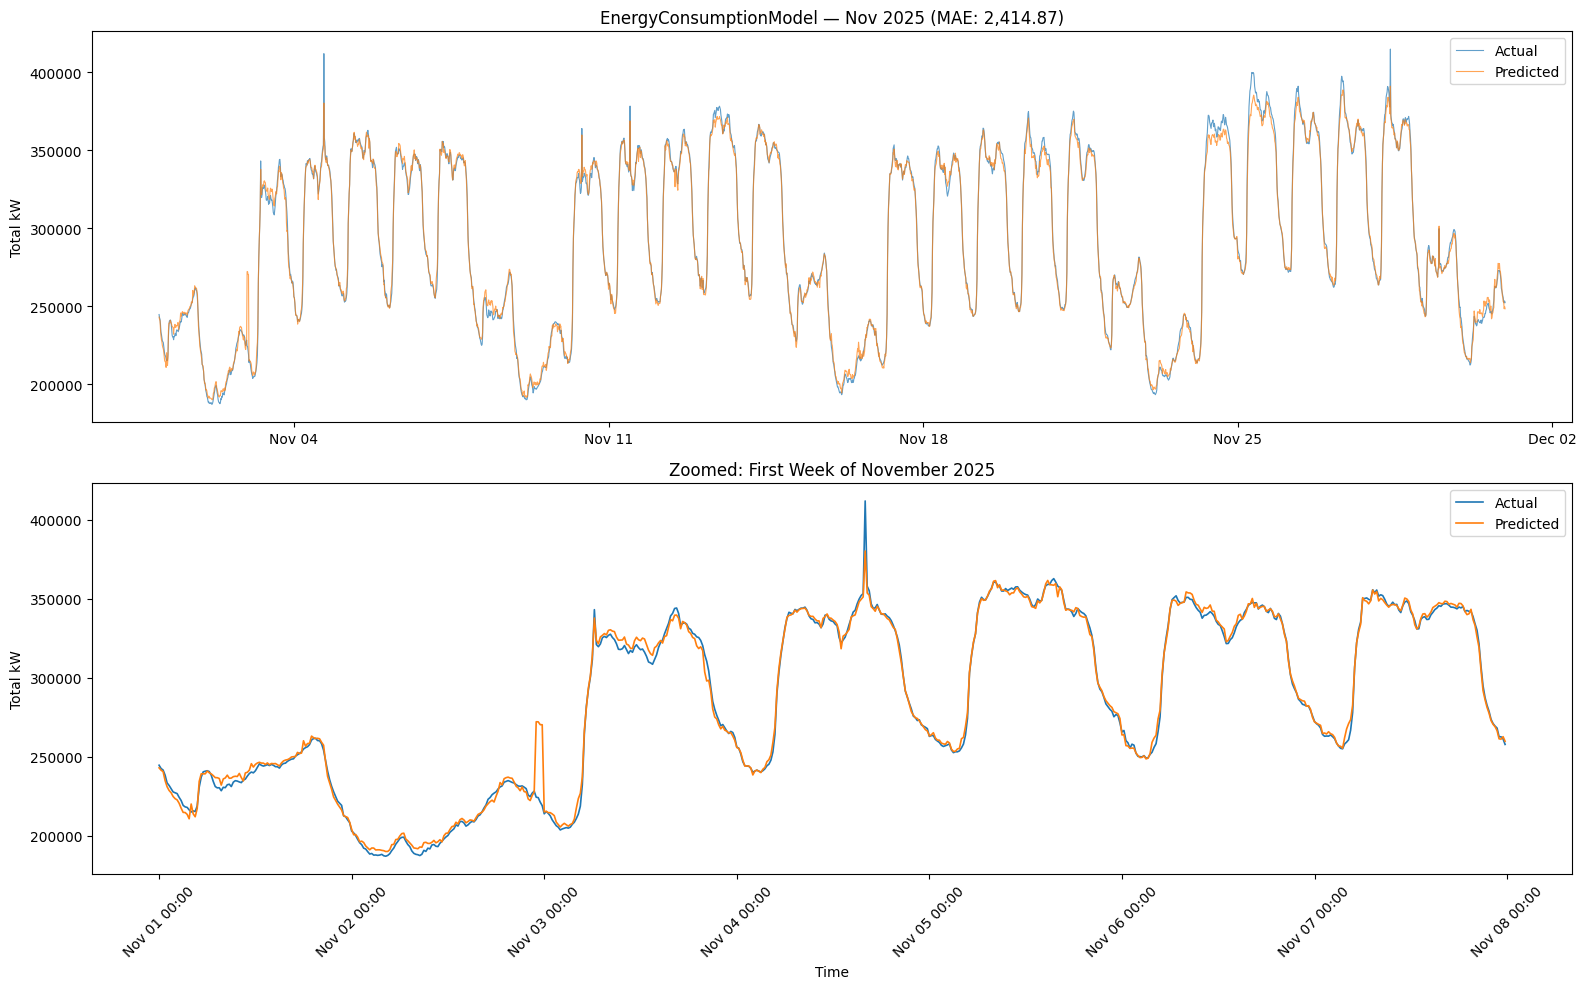

In [0]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Collect predictions and actuals for November 2025
local_preds_pdf = local_preds.toPandas().sort_values("datetime_15min").reset_index(drop=True)
actuals_local_pdf = actuals_local.toPandas().sort_values("datetime_15min").reset_index(drop=True)

# Align on datetime_15min
merged_pdf = local_preds_pdf.merge(actuals_local_pdf, on="datetime_15min", how="inner")
dt = pd.to_datetime(merged_pdf["datetime_15min"])
y_pred = merged_pdf["prediction"].values
y_true = merged_pdf["active_kw"].values

# MAE
mae = np.mean(np.abs(y_true - y_pred))

# Plot: Month and first week
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Month
axes[0].plot(dt, y_true, label="Actual", alpha=0.7, linewidth=0.8)
axes[0].plot(dt, y_pred, label="Predicted", alpha=0.7, linewidth=0.8)
axes[0].set_title(f"EnergyConsumptionModel — Nov 2025 (MAE: {mae:,.2f})")
axes[0].set_ylabel("Total kW")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator())

# First week
mask_week = (dt >= "2025-11-01") & (dt < "2025-11-08")
axes[1].plot(dt[mask_week], y_true[mask_week], label="Actual", linewidth=1.2)
axes[1].plot(dt[mask_week], y_pred[mask_week], label="Predicted", linewidth=1.2)
axes[1].set_title("Zoomed: First Week of November 2025")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Total kW")
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
axes[1].xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**NOTE: Lookahead bias threat due to use of lag_1d feature**